In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import omegaconf
from shell.utils.experiment_utils import *
from shell.fleet.utils.fleet_utils import *
from shell.utils.metric import *
import matplotlib.pyplot as plt
from shell.fleet.network import TopologyGenerator
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
from shell.fleet.fleet import Agent, Fleet
from shell.fleet.data.data_utilize import *
from shell.fleet.data.recv import *

from sklearn.manifold import TSNE
from torchvision.utils import make_grid
from shell.fleet.data.data_utilize import *
import logging
from sklearn.metrics import f1_score
import os
from shell.fleet.data.recv_utils import *
from tqdm import tqdm
import argparse
from functools import partial
from torchvision.utils import make_grid
from shell.utils.oodloss import OODSeparationLoss
from pythresh.thresholds.dsn import DSN
from pythresh.thresholds.aucp import AUCP
from pythresh.thresholds.boot import BOOT
from pythresh.thresholds.zscore import ZSCORE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import defaultdict

from shell.fleet.network import *
logging.basicConfig(level=logging.INFO)

In [3]:

# modmod
experiment_name = "leep_jorge_setting_lowest_task_id_wins_modmod_test_sync_base_True_opt_with_random_False_frozen_False_transfer_decoder_True_transfer_structure_True_no_sparse_basis_True"
experiment_folder = "experiment_results"



dataset = "combined"
algo = "modular"


use_contrastive = False
num_trains_per_class = 64 if dataset != "cifar100" else 256
# seed = 0
seed = 5
num_tasks = 10
parallel = False

In [4]:
def modify_cfg(net_cfg, agent_cfg, train_cfg, fleet_additional_cfg, cfg):
    # cfg.sharing_strategy["sync_base"] = False


    cfg.sharing_strategy = DictConfig({
        "name": "modmod",
        "num_coms_per_round": 2,
        "module_selection": "gt_most_similar",
        "pre_or_post_comm": "pre",
        "ranker": "label",
        "module_select": "tryout",
        "num_shared_module": 1,
        "num_tryout_epochs": 10,
        "max_num_modules_tryout": 1,
        "sync_base":True,
    })
    return net_cfg, agent_cfg, train_cfg, fleet_additional_cfg, cfg

In [5]:
def get_communication(fleet, multiplier=1, exponential=False):
    N = len(fleet.agents)

    # Initialize matrices for summing task_sim values and counting occurrences
    communication_sum = np.zeros((N, N))
    communication_count = np.zeros((N, N))

    for i, agent in enumerate(fleet.agents):
        df = agent.modmod_record.df
        for _, row in df.iterrows():
            j = int(row['neighbor_id'])
            communication_sum[i, j] += row['task_sim']
            communication_count[i, j] += 1

    # Calculate the average only where there's at least one occurrence
    with np.errstate(divide='ignore', invalid='ignore'):  # Ignore division by zero
        communication_avg = np.divide(communication_sum, communication_count, out=np.zeros_like(
            communication_sum), where=communication_count != 0)

    if exponential:
        # Apply exponential function to non-zero averages
        communication_avg[communication_avg != 0] = np.exp(
            communication_avg[communication_avg != 0] * multiplier)

    return communication_avg, communication_count



In [6]:
comms = []
for seed in range(8):
    save_dir = get_save_dir(experiment_folder, experiment_name,
                            dataset, algo, num_trains_per_class, use_contrastive, seed)

    fleet = setup_fleet(save_dir, task_id=None, parallel=False, modify_cfg=modify_cfg)
    fleet.change_save_dir('combined_dataset_engineering_experiment_results')
    set_color(fleet)
    task_sim ,communication = get_communication(fleet)
    comms.append(communication)
# edge_widths = set_weight(fleet, communication)

INFO:root:Setting seed 0


INFO:root:Class sequence: [5 0 4 3 4 6 4 3 8 0 1 0 5 9 6 4 9 0 3 0]
INFO:root:task 0 :(128, 1, 28, 28) (100, 1, 28, 28) (1872, 1, 28, 28)
INFO:root:task 1 :(128, 1, 28, 28) (100, 1, 28, 28) (1992, 1, 28, 28)
INFO:root:task 2 :(128, 1, 28, 28) (100, 1, 28, 28) (1940, 1, 28, 28)
INFO:root:task 3 :(128, 1, 28, 28) (100, 1, 28, 28) (1992, 1, 28, 28)


{'train': {'component_update_freq': 100, 'num_epochs': 100, 'init_component_update_freq': 100, 'init_num_epochs': 100, 'save_freq': 10}, 'dataset': {'dataset_name': 'combined', 'num_tasks': 10, 'num_classes_per_task': 2, 'with_replacement': True, 'num_trains_per_class': 64, 'num_vals_per_class': 50, 'remap_labels': True}, 'net': {'name': 'mlp', 'depth': 4, 'layer_size': 64, 'dropout': 0.5, 'no_sparse_basis': True}, 'sharing_strategy': {'name': 'modmod', 'num_coms_per_round': 2, 'module_selection': 'gt_most_similar', 'pre_or_post_comm': 'pre', 'opt_with_random': False, 'comm_freq': 100, 'sync_base': True, 'freeze_candidate_module': False, 'transfer_decoder': True, 'transfer_structure': True, 'ranker': 'instance', 'module_select': 'trust_sim', 'num_shared_module': 1}, 'seed': 0, 'algo': 'modular', 'job_name': 'combined_modular_numtrain_64', 'num_agents': 20, 'root_save_dir': 'combined_data_experiment_results/leep_jorge_setting_lowest_task_id_wins_modmod_test_sync_base_True_opt_with_rando

INFO:root:task 4 :(128, 1, 28, 28) (100, 1, 28, 28) (1954, 1, 28, 28)
INFO:root:task 5 :(128, 1, 28, 28) (100, 1, 28, 28) (2115, 1, 28, 28)
INFO:root:task 6 :(128, 1, 28, 28) (100, 1, 28, 28) (1901, 1, 28, 28)
INFO:root:task 7 :(128, 1, 28, 28) (100, 1, 28, 28) (1940, 1, 28, 28)
INFO:root:task 8 :(128, 1, 28, 28) (100, 1, 28, 28) (1989, 1, 28, 28)
INFO:root:task 9 :(128, 1, 28, 28) (100, 1, 28, 28) (1990, 1, 28, 28)
INFO:root:Class sequence: [4 7 5 7 6 0 3 0 5 0 3 6 2 7 6 7 6 1 0 5]
INFO:root:task 0 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 1 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 2 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 3 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 4 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 5 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 6 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 7 :(128

i_size 28
num_classes 2
net_cfg {'name': 'mlp', 'depth': 4, 'layer_size': 64, 'dropout': 0.5, 'no_sparse_basis': True, 'i_size': 28, 'num_classes': 2, 'num_tasks': 10, 'num_init_tasks': 4, 'use_contrastive': False}
<class 'shell.learners.er_dynamic.CompositionalDynamicER'>


...

i_size 28
num_classes 2
net_cfg {'name': 'mlp', 'depth': 4, 'layer_size': 64, 'dropout': 0.5, 'no_sparse_basis': True, 'i_size': 28, 'num_classes': 2, 'num_tasks': 10, 'num_init_tasks': 4, 'use_contrastive': False}
<class 'shell.learners.er_dynamic.CompositionalDynamicER'>
{'train': {'component_update_freq': 100, 'num_epochs': 100, 'init_component_update_freq': 100, 'init_num_epochs': 100, 'save_freq': 10}, 'dataset': {'dataset_name': 'combined', 'num_tasks': 10, 'num_classes_per_task': 2, 'with_replacement': True, 'num_trains_per_class': 64, 'num_vals_per_class': 50, 'remap_labels': True}, 'net': {'name': 'mlp', 'depth': 4, 'layer_size': 64, 'dropout': 0.5, 'no_sparse_basis': True}, 'sharing_strategy': {'name': 'modmod', 'num_coms_per_round': 2, 'module_selection': 'gt_most_similar', 'pre_or_post_comm': 'pre', 'opt_with_random': False, 'comm_freq': 100, 'sync_base': True, 'freeze_candidate_module': False, 'transfer_decoder': True, 'transfer_structure': True, 'ranker': 'instance', 'mod

INFO:root:Class sequence: [2 3 4 8 8 7 6 9 2 9 1 8 8 7 8 7 4 7 0 2]
INFO:root:task 0 :(128, 1, 28, 28) (100, 1, 28, 28) (2042, 1, 28, 28)
INFO:root:task 1 :(128, 1, 28, 28) (100, 1, 28, 28) (1956, 1, 28, 28)
INFO:root:task 2 :(128, 1, 28, 28) (100, 1, 28, 28) (2002, 1, 28, 28)
INFO:root:task 3 :(128, 1, 28, 28) (100, 1, 28, 28) (1967, 1, 28, 28)
INFO:root:task 4 :(128, 1, 28, 28) (100, 1, 28, 28) (2041, 1, 28, 28)
INFO:root:task 5 :(128, 1, 28, 28) (100, 1, 28, 28) (2109, 1, 28, 28)
INFO:root:task 6 :(128, 1, 28, 28) (100, 1, 28, 28) (2002, 1, 28, 28)
INFO:root:task 7 :(128, 1, 28, 28) (100, 1, 28, 28) (2002, 1, 28, 28)
INFO:root:task 8 :(128, 1, 28, 28) (100, 1, 28, 28) (2010, 1, 28, 28)
INFO:root:task 9 :(128, 1, 28, 28) (100, 1, 28, 28) (2012, 1, 28, 28)
INFO:root:Class sequence: [9 4 5 4 5 3 1 3 5 8 3 1 0 7 4 0 3 1 7 6]
INFO:root:task 0 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 1 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 2 :(128, 

i_size 28
num_classes 2
net_cfg {'name': 'mlp', 'depth': 4, 'layer_size': 64, 'dropout': 0.5, 'no_sparse_basis': True, 'i_size': 28, 'num_classes': 2, 'num_tasks': 10, 'num_init_tasks': 4, 'use_contrastive': False}
<class 'shell.learners.er_dynamic.CompositionalDynamicER'>
{'train': {'component_update_freq': 100, 'num_epochs': 100, 'init_component_update_freq': 100, 'init_num_epochs': 100, 'save_freq': 10}, 'dataset': {'dataset_name': 'combined', 'num_tasks': 10, 'num_classes_per_task': 2, 'with_replacement': True, 'num_trains_per_class': 64, 'num_vals_per_class': 50, 'remap_labels': True}, 'net': {'name': 'mlp', 'depth': 4, 'layer_size': 64, 'dropout': 0.5, 'no_sparse_basis': True}, 'sharing_strategy': {'name': 'modmod', 'num_coms_per_round': 2, 'module_selection': 'gt_most_similar', 'pre_or_post_comm': 'pre', 'opt_with_random': False, 'comm_freq': 100, 'sync_base': True, 'freeze_candidate_module': False, 'transfer_decoder': True, 'transfer_structure': True, 'ranker': 'instance', 'mod

INFO:root:Class sequence: [9 5 2 9 1 2 0 1 7 2 3 6 1 3 6 4 3 5 9 2]
INFO:root:task 0 :(128, 1, 28, 28) (100, 1, 28, 28) (1901, 1, 28, 28)
INFO:root:task 1 :(128, 1, 28, 28) (100, 1, 28, 28) (2041, 1, 28, 28)
INFO:root:task 2 :(128, 1, 28, 28) (100, 1, 28, 28) (2167, 1, 28, 28)
INFO:root:task 3 :(128, 1, 28, 28) (100, 1, 28, 28) (2115, 1, 28, 28)
INFO:root:task 4 :(128, 1, 28, 28) (100, 1, 28, 28) (2060, 1, 28, 28)
INFO:root:task 5 :(128, 1, 28, 28) (100, 1, 28, 28) (1968, 1, 28, 28)
INFO:root:task 6 :(128, 1, 28, 28) (100, 1, 28, 28) (2145, 1, 28, 28)
INFO:root:task 7 :(128, 1, 28, 28) (100, 1, 28, 28) (1940, 1, 28, 28)
INFO:root:task 8 :(128, 1, 28, 28) (100, 1, 28, 28) (1902, 1, 28, 28)
INFO:root:task 9 :(128, 1, 28, 28) (100, 1, 28, 28) (2041, 1, 28, 28)
INFO:root:Class sequence: [3 9 9 5 7 2 9 6 0 7 4 5 2 1 3 9 9 4 6 5]
INFO:root:task 0 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 1 :(128, 1, 28, 28) (100, 1, 28, 28) (2000, 1, 28, 28)
INFO:root:task 2 :(128, 

i_size 28
num_classes 2
net_cfg {'name': 'mlp', 'depth': 4, 'layer_size': 64, 'dropout': 0.5, 'no_sparse_basis': True, 'i_size': 28, 'num_classes': 2, 'num_tasks': 10, 'num_init_tasks': 4, 'use_contrastive': False}
<class 'shell.learners.er_dynamic.CompositionalDynamicER'>


In [81]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import io

def plot_graph(G: nx.Graph,
               node_color_attr='dataset',
               edge_color='#bfbfbf',
               node_size=300,
               font_size=10,
               font_family="sans-serif",
               draw_labels=False,
               save_path=None,
               edge_widths=1,
               image_paths=None,
               ax=None):
    print("save_path", save_path)
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 12))

    # Get unique dataset values
    datasets = list(set(nx.get_node_attributes(G, node_color_attr).values()))
    print('datasets', datasets)
    
    # Define positions for each dataset cluster
    cluster_positions = {
        datasets[0]: (0.25, 0.25),  # bottom-left
        datasets[1]: (0.75, 0.25),  # bottom-right
        datasets[2]: (0.5, 0.75)    # top
    }

    # Create a position dictionary for nodes
    pos = {}
    for node, data in G.nodes(data=True):
        dataset = data[node_color_attr]
        base_x, base_y = cluster_positions[dataset]
        # Add some random jitter to spread nodes within their cluster
        pos[node] = (
            base_x + np.random.normal(0, 0.05),
            base_y + np.random.normal(0, 0.05)
        )

    # Determine node colors based on the attribute
    unique_attrs = set(nx.get_node_attributes(G, node_color_attr).values())
    color_map = plt.cm.get_cmap('Set1')(np.linspace(0, 1, len(unique_attrs)))
    color_dict = dict(zip(unique_attrs, color_map))
    node_colors = [color_dict[G.nodes[n].get(node_color_attr, 'default')] for n in G.nodes()]

    # Draw edges with alpha for better visibility
    edge_color_rgba = to_rgba(edge_color, alpha=0.2)
    nx.draw_networkx_edges(G, pos, edge_color=edge_color_rgba, width=edge_widths, ax=ax)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax, alpha=0.8)

    if draw_labels:
        nx.draw_networkx_labels(G, pos, font_size=font_size, font_family=font_family, ax=ax)

    # Add representative images for each cluster
    if image_paths:
        print(image_paths)
        for dataset, (x, y) in cluster_positions.items():
            img_path = image_paths.get(dataset)
            if img_path:
                # Load and resize the image
                img = Image.open(img_path)
                img_size = 150
                img = img.resize((img_size, img_size), Image.ANTIALIAS)
                print(img)
                
                # Convert PIL image to matplotlib image
                buf = io.BytesIO()
                img.save(buf, format='PNG')
                buf.seek(0)
                img = plt.imread(buf)
                
                # Create an OffsetImage
                imagebox = OffsetImage(img, zoom=0.5)
                imagebox.image.axes = ax

                # Adjust image position based on cluster location
                if y > 0.5:  # Top cluster
                    offset_y = 0.2
                    offset_x = 0
                elif x < 0.5:  # Bottom-left cluster
                    offset_y = 0
                    offset_x = -0.2
                else:  # Bottom-right cluster
                    offset_y = 0
                    offset_x = 0.2

                # Create an AnnotationBbox with adjusted position
                ab = AnnotationBbox(imagebox, (x + offset_x, y + offset_y),
                                    xycoords='data',
                                    boxcoords="offset points",
                                    box_alignment=(0.5, 0.5),
                                    pad=0.5,
                                    bboxprops=dict(edgecolor=color_dict[dataset], linewidth=3, facecolor='white'))

                # Add the AnnotationBbox to the axes
                ax.add_artist(ab)

    # Improve overall aesthetics
    ax.set_facecolor('#f0f0f0')  # Light gray background
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.1, 1.2)
    ax.set_axis_off()
    plt.tight_layout()

    if save_path:
        print(f"Saving plot to {save_path}")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return ax

In [82]:
def set_weight(fleet, communication):
    G = fleet.graph
    for i, (u, v, d) in enumerate(G.edges(data=True)):
        # Assuming u, v are indices in the communication matrix
        if u < len(communication) and v < len(communication):
            d['weight'] = communication[u, v]
    edge_widths = [d['weight'] for _, _, d in G.edges(data=True)]
    return edge_widths




def normalize_edge_widths(edge_widths, min_width=1, max_width=10):
    if not edge_widths:
        return []
    
    # Convert to numpy array for easier manipulation
    weights = np.array(edge_widths)
    
    # Normalize weights to [0, 1] range
    normalized = (weights - np.min(weights)) / (np.max(weights) - np.min(weights))
    
    # Apply quadratic scaling
    quadratic = normalized ** 2
    # quadratic = normalized 
    
    # Scale to desired width range
    scaled_widths = quadratic * (max_width - min_width) + min_width
    
    return scaled_widths.tolist()


In [83]:
communication = np.mean(comms, axis=0)
edge_widths = set_weight(fleet, communication)
edge_widths = normalize_edge_widths(edge_widths, min_width=0, max_width=2)

In [84]:
len(edge_widths)

190

INFO:root:Setting seed 0


save_path Figures/rebuttal/neurips_rebuttal_combined.pdf
datasets ['#E41A1C', '#4DAF4A', '#377EB8']
{'#377EB8': 'Figures/datasets/mnist.png', '#4DAF4A': 'Figures/datasets/kmnist.png', '#E41A1C': 'Figures/datasets/fashionmnist.png'}
<PIL.Image.Image image mode=RGBA size=150x150 at 0x7FF96C498100>
<PIL.Image.Image image mode=RGBA size=150x150 at 0x7FF96C49AC80>
<PIL.Image.Image image mode=RGBA size=150x150 at 0x7FF96C49B160>
Saving plot to Figures/rebuttal/neurips_rebuttal_combined.pdf


/tmp/ipykernel_2341933/2431134634.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('Set1')(np.linspace(0, 1, len(unique_attrs)))
/tmp/ipykernel_2341933/2431134634.py:71: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  img = img.resize((img_size, img_size), Image.ANTIALIAS)


<Axes: >

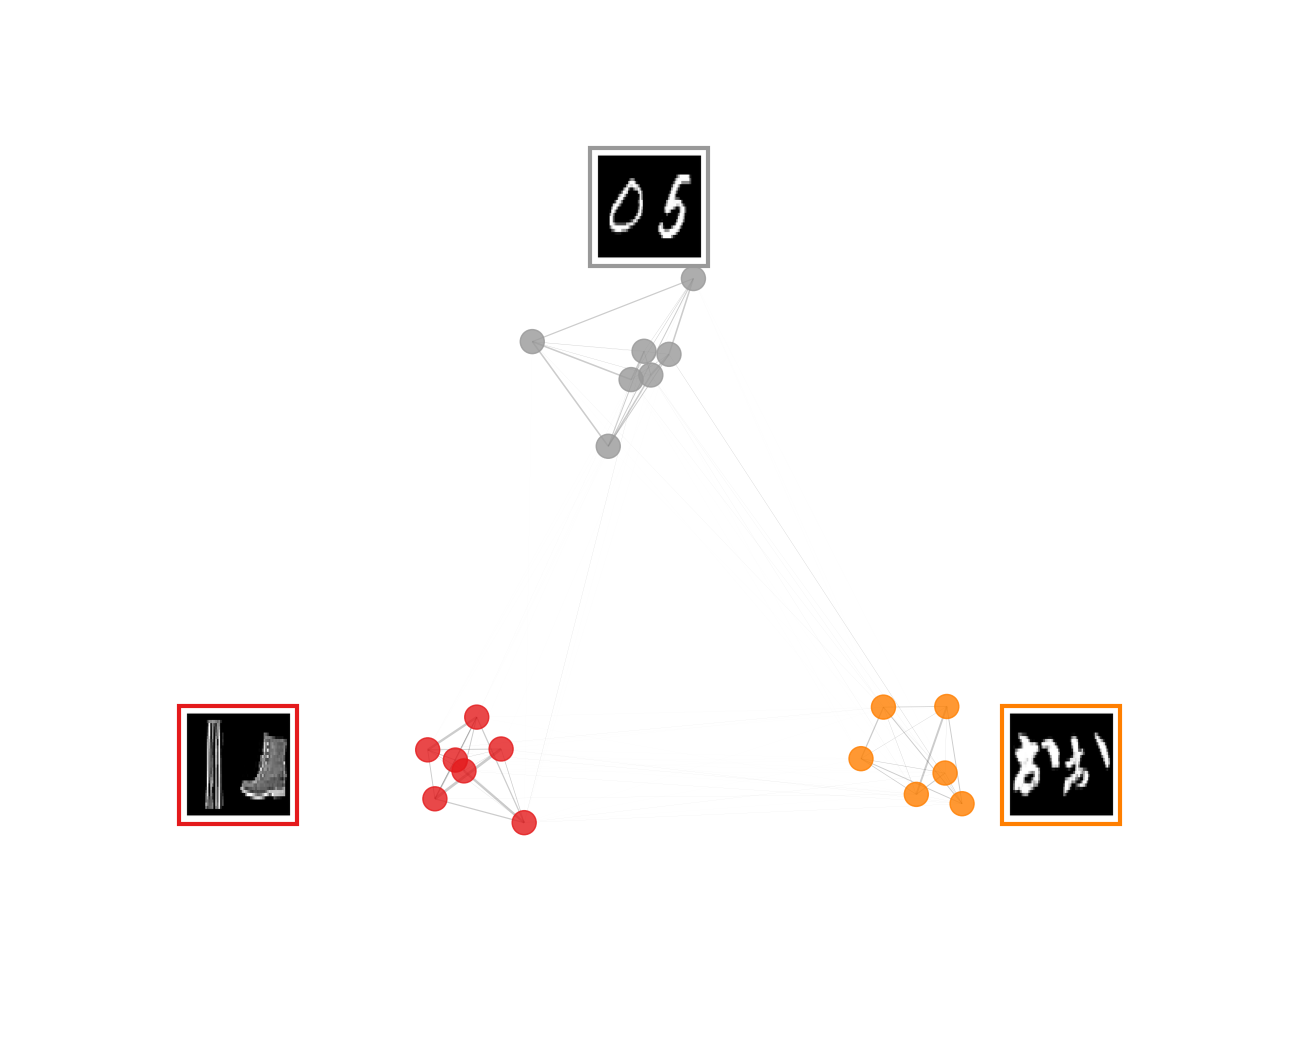

In [85]:
image_paths = {
    '#377EB8': 'Figures/datasets/mnist.png',
    '#4DAF4A': 'Figures/datasets/kmnist.png',
    '#E41A1C': 'Figures/datasets/fashionmnist.png',
}


seed_everything(0)
plot_graph(fleet.graph, node_color_attr='dataset',
                            edge_color='black',
                            edge_widths=edge_widths,
                            image_paths=image_paths,
                            save_path="Figures/rebuttal/neurips_rebuttal_combined.pdf")

In [86]:
# communication = get_communication(fleet,multiplier=1)

_, trans_communication = get_communication(fleet,multiplier=1)
in_clus, out_clus = compute_cluster_communications(fleet, trans_communication)
in_clus, out_clus

(0.7719298245614035, 0.045112781954887216)